- Set up model running function in external script
- Call this function to do parameter scans

In [1]:
import xarray as xr

import numpy as np

import time as tm

from multiprocessing import Pool

import warnings
warnings.simplefilter(action='ignore', category=(RuntimeWarning, FutureWarning))

In [2]:
from func_parallel import run_model_test

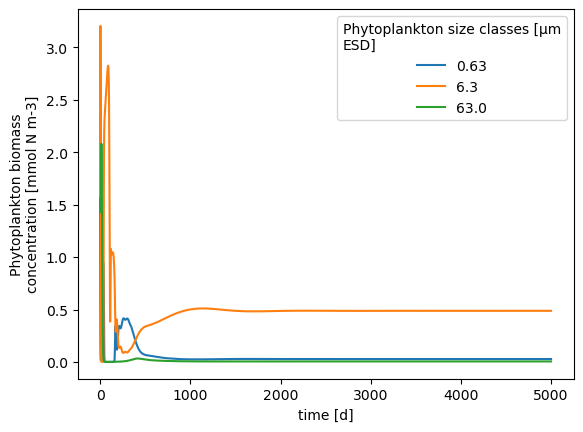

In [3]:
outttttt = run_model_test({'HigherOrderMortality__rate': 0.009})#.Phytoplankton__biomass.plot.line(x='time')
outttttt.Phytoplankton__biomass.plot.line(x='time')

In [4]:
def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, [{par1:val1, par2:val2} for val2 in par_range2])) for val1 in par_range1]

In [5]:
def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
        #print(var, val, var2)
        dat_out = []
        for out in dat:
            #print(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [6]:
def run_model_get_output(iterable_in):

    p = Pool()
    print("pool started")
    start = tm.time()
    data_2d = []
    for iter_par1, (iter_val1, iter_par2, iter_vals2) in iterable_in:
        print("running", iter_par1, iter_val1, iter_par2)#, iter_vals2)
        data_2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))
    
    end = tm.time()
    p.close()
    print("Full scan done in ",round(end-start,5),"seconds")

    scan_output = unpack_2d_par_scan(data_2d)
    return scan_output

In [13]:
from IPython.display import display, clear_output

def run_model_get_output_progress(iterable_in):
    total_iterations = len(iterable_in)  # Total number of iterations

    p = Pool()
    print("Pool started")
    start = tm.time()
    data_2d = []

    for i, (iter_par1, (iter_val1, iter_par2, iter_vals2)) in enumerate(iterable_in, start=1):
        print(f"Running iteration {i}/{total_iterations}: {iter_par1} = {iter_val1}, {iter_par2}")
        data_2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))
        # Clear previous output
        clear_output(wait=True)

    end = tm.time()
    p.close()
    print("Full scan done in", round(end - start, 5), "seconds")

    scan_output = unpack_2d_par_scan(data_2d)
    return scan_output


In [9]:
gge_mort_scan_input = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.008,0.01, 5),
                                                   'GGE__gge', np.linspace(0.2,0.4, 50))

gge_mort_scan = run_model_get_output_progress(gge_mort_scan_input)

Running iteration 5/5: HigherOrderMortality__rate = 0.01, GGE__gge
Full scan done in 28.21791 seconds


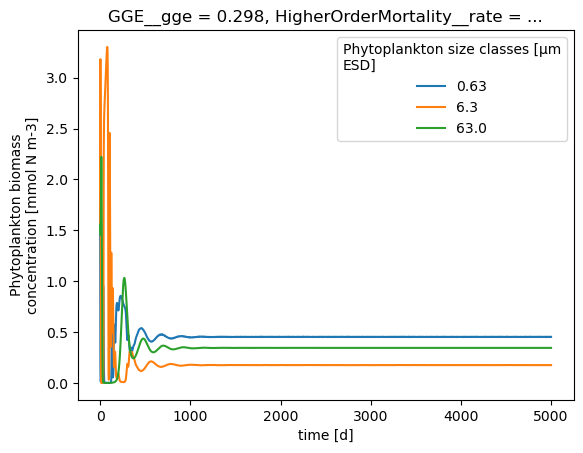

In [10]:
gge_mort_scan.isel(GGE__gge=24, HigherOrderMortality__rate=1).Phytoplankton__biomass.plot.line(x='time')

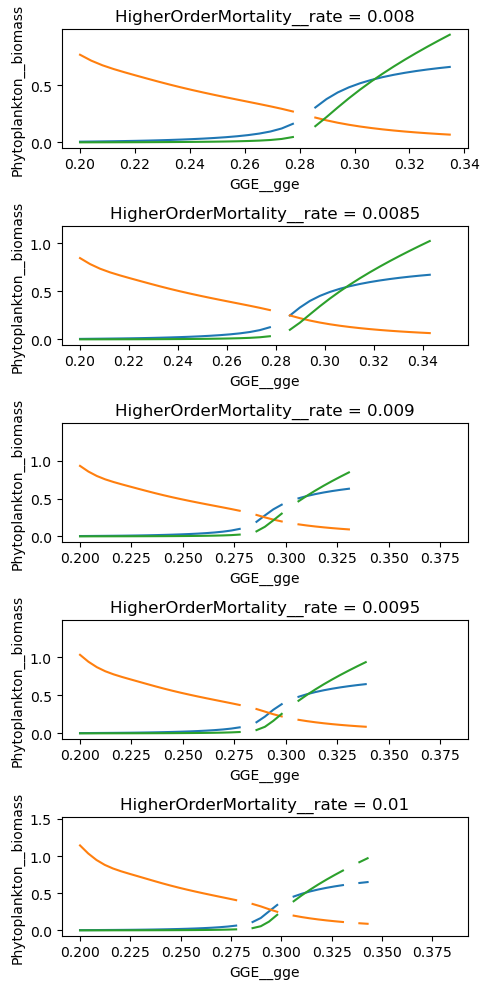

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (gge_mort_scan
        .isel(time=slice(365*9,365*10), HigherOrderMortality__rate=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='GGE__gge', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

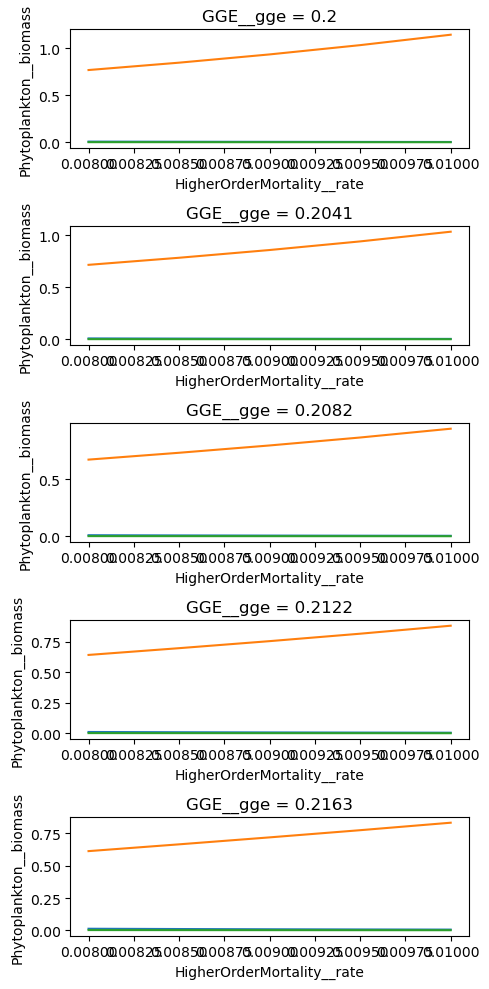

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (gge_mort_scan
        .isel(time=slice(365*9,365*10), GGE__gge=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

In [ ]:
# Now lets test Ks as a par

In [ ]:
KsZ_mort_scan_input = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.001,0.0035, 5),
                                                   'Grazing__KsZ', np.linspace(2.0,4.0, 50))

KsZ_mort_scan = run_model_get_output_progress(KsZ_mort_scan_input)

Running iteration 2/5: HigherOrderMortality__rate = 0.0016250000000000001, Grazing__KsZ


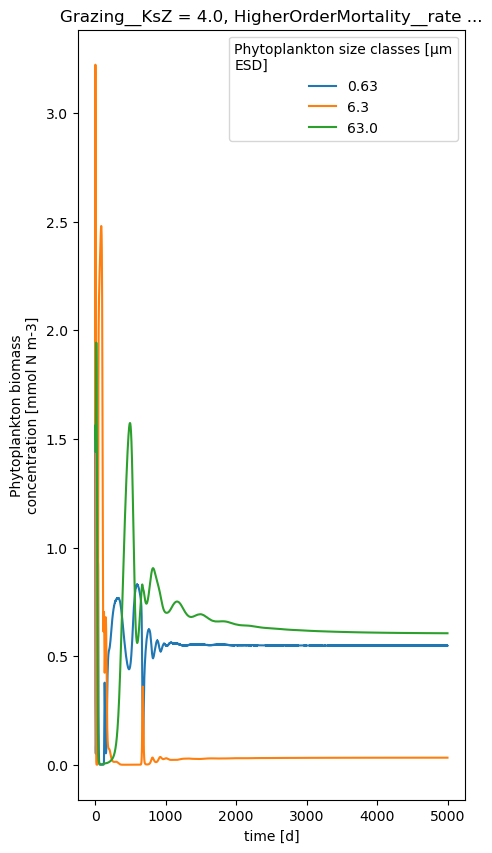

In [27]:
KsZ_mort_scan.isel(Grazing__KsZ=49, HigherOrderMortality__rate=1).Phytoplankton__biomass.plot.line(x='time')

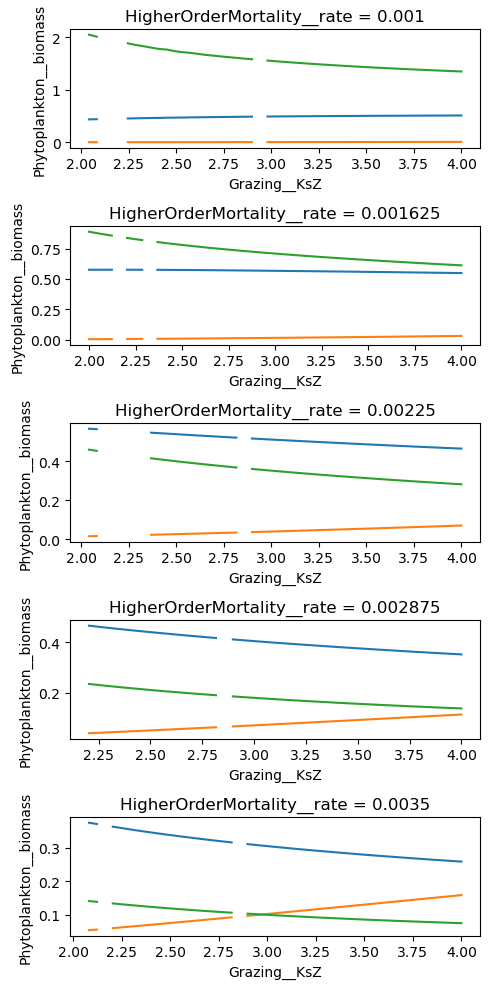

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (KsZ_mort_scan
        .isel(time=slice(365*9,365*10), HigherOrderMortality__rate=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='Grazing__KsZ', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

In [30]:
KsZ_mort_scan

<xarray.Dataset> Size: 630MB
Dimensions:                                         (Grazing__KsZ: 50,
                                                     HigherOrderMortality__rate: 5,
                                                     zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
  * Grazing__KsZ                                    (Grazing__KsZ) float64 400B ...
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (Grazing__KsZ, HigherOrderMortality__rate) <U9 9kB ...
    GGE__R                                          (Grazing__KsZ, HigherOrderMortality__rate) float64 2kB ...
    GGE__alpha                                      (Grazing__KsZ, HigherOrderMortality__rate) float64 2kB ...
    GGE__assimilated_consumer                       (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    GGE__assimilation_value                         (Grazing__KsZ, HigherOrderMortality__rate, zoo, time) float64 40MB ...
    GGE__egested_detritus                           (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    ...                                              ...
    Phytoplankton__phyto_index                      (Grazing__KsZ, HigherOrderMortality__rate, phyto) float64 6kB ...
    Time__time_input                                (Grazing__KsZ, HigherOrderMortality__rate, time) int64 10MB ...
    Zooplankton__biomass                            (Grazing__KsZ, HigherOrderMortality__rate, zoo, time) float64 40MB ...
    Zooplankton__biomass_init                       (Grazing__KsZ, HigherOrderMortality__rate, zoo) float64 8kB ...
    Zooplankton__biomass_label                      (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    Zooplankton__zoo_index                          (Grazing__KsZ, HigherOrderMortality__rate, zoo) float64 8kB ...

In [16]:
KsZ_mort_scan_input_X = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.001,0.04, 100),
                                                   'GGE__gge', np.linspace(0.1,0.5, 100))

KsZ_mort_scan_X = run_model_get_output_progress(KsZ_mort_scan_input_X)

Full scan done in 2899.4926 seconds


0.0009692889483591136


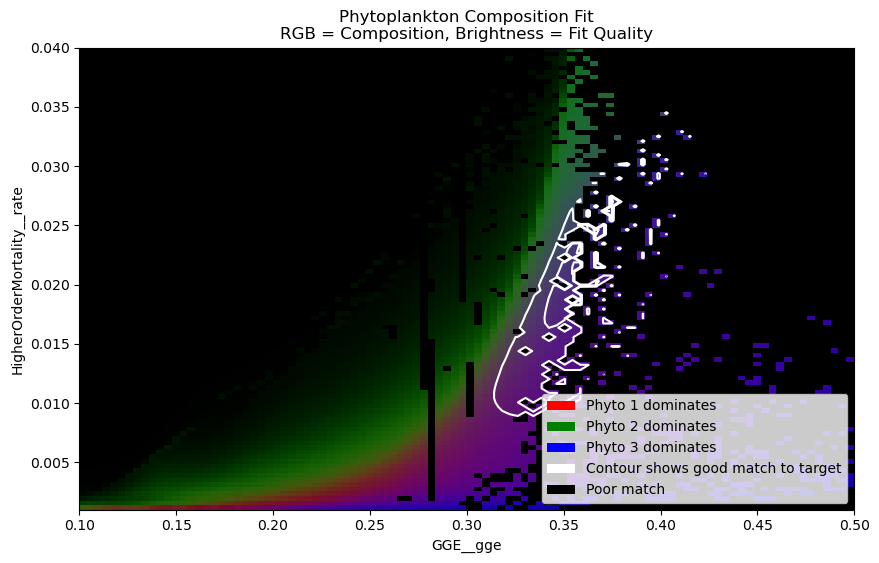

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr

# --- Parameters ---
target_composition = np.array([0.261, 0.199, 0.539])  # Replace with your desired target
start_time = 365 * 9
end_time = 365 * 10

# --- Slice and average over the last year ---
biomass = KsZ_mort_scan_X.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose so dimensions are (HigherOrderMortality__rate, GGE__gge, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'GGE__gge', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
rel_np = relative_composition.values  # shape: (rate, gge, phyto)
dist = np.linalg.norm(rel_np - target_composition, axis=2)  # shape: (rate, gge)
print(dist.min())
# Normalize and compute brightness
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm

# Apply gamma correction
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]

# Clean up RGB array for imshow
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
x_vals = biomass_mean.GGE__gge.values  # Horizontal axis
y_vals = biomass_mean.HigherOrderMortality__rate.values  # Vertical axis
X, Y = np.meshgrid(x_vals, y_vals)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.imshow(rgb, origin='lower', aspect='auto',
           extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()])
plt.xlabel('GGE__gge')
plt.ylabel('HigherOrderMortality__rate')
plt.title('Phytoplankton Composition Fit\nRGB = Composition, Brightness = Fit Quality')
plt.grid(False)

# Overlay contour for perfect match
cs = plt.contour(X, Y, dist,levels = [0.02, 0.05, 0.1, 0.2] , colors='white', linewidths=1.5)
#plt.clabel(cs, fmt='Perfect match', inline=True)


legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour shows good match to target'),
    Patch(facecolor='black', label='Poor match')
]
plt.legend(handles=legend_elements, loc='lower right')


plt.show()

In [18]:
# Find the index of the minimum distance
flat_index = np.argmin(dist)
best_i, best_j = np.unravel_index(flat_index, dist.shape)

# If you transposed `dist` earlier, adjust the indices
if dist.shape != (len(y_vals), len(x_vals)):
    best_j, best_i = best_i, best_j

# Retrieve the corresponding parameter values
best_gge = x_vals[best_j]
best_mortality = y_vals[best_i]
best_dist = dist[best_i, best_j]

# Print result
print(f"Best fit found at:")
print(f"  GGE__gge = {best_gge}")
print(f"  HigherOrderMortality__rate = {best_mortality}")
print(f"  Distance to target = {best_dist}")

Best fit found at:
  GGE__gge = 0.37070707070707076
  HigherOrderMortality__rate = 0.026212121212121214
  Distance to target = 0.0009692889483591136


0.03614679676523351


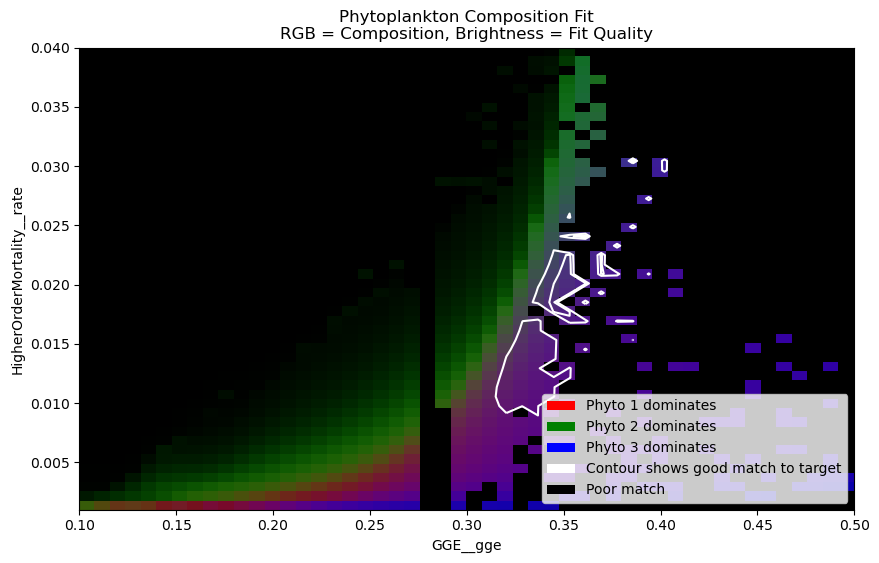

Best fit found at:
  GGE__gge = 0.36122448979591837
  HigherOrderMortality__rate = 0.024081632653061225
  Distance to target = 0.03614679676523351
